### Note

This notebook reflects an exploratory learning approach to understanding how
different machine learning models behave on credit risk data. The focus is on
studying modeling choices and evaluation trade-offs rather than building a
production-ready system.


In [1]:



import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import recall_score

from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("GermanCreditData.csv")
df.head()


,status,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,credit_risk
0,... < 100 DM,6,critical account/other credits existing,domestic appliances,1169,unknown/no savings account,... >= 7 years,4,male : single,none,...,real estate,67,none,own,2,skilled employee/official,1,yes,yes,1
1,0 <= ... < 200 DM,48,existing credits paid back duly till now,domestic appliances,5951,... < 100 DM,1 <= ... < 4 years,2,female : divorced/separated/married,none,...,real estate,22,none,own,1,skilled employee/official,1,no,yes,0
2,no checking account,12,critical account/other credits existing,retraining,2096,... < 100 DM,4 <= ... < 7 years,2,male : single,none,...,real estate,49,none,own,1,unskilled - resident,2,no,yes,1
3,... < 100 DM,42,existing credits paid back duly till now,radio/television,7882,... < 100 DM,4 <= ... < 7 years,2,male : single,guarantor,...,building society savings agreement/life insurance,45,none,for free,1,skilled employee/official,2,no,yes,1
4,... < 100 DM,24,delay in paying off in the past,car (new),4870,... < 100 DM,1 <= ... < 4 years,3,male : single,none,...,unknown/no property,53,none,for free,2,skilled employee/official,2,no,yes,0


In [3]:
df["credit_risk"].value_counts()

,count
credit_risk,
1,700
0,300


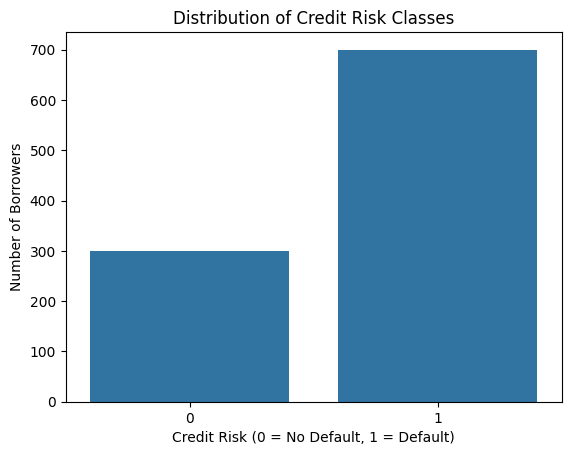

In [4]:
sns.countplot(x=df["credit_risk"])
plt.title("Distribution of Credit Risk Classes")
plt.xlabel("Credit Risk (0 = No Default, 1 = Default)")
plt.ylabel("Number of Borrowers")
plt.show()

In [5]:
X = df.drop("credit_risk", axis=1)
y = df["credit_risk"]

X.shape, y.shape


((1000, 20), (1000,))

In [6]:
categorical_cols = X.select_dtypes(include=["object"]).columns
numerical_cols = X.select_dtypes(exclude=["object"]).columns

categorical_cols, numerical_cols


(Index(['status', 'credit_history', 'purpose', 'savings', 'employment_duration',
        'personal_status_sex', 'other_debtors', 'property',
        'other_installment_plans', 'housing', 'job', 'telephone',
        'foreign_worker'],
       dtype='object'),
 Index(['duration', 'amount', 'installment_rate', 'present_residence', 'age',
        'number_credits', 'people_liable'],
       dtype='object'))

In [7]:
X_encoded = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True
)



In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)



In [9]:
print("Training set distribution:")
print(y_train.value_counts())

print("\nTest set distribution:")
print(y_test.value_counts())

Training set distribution:
credit_risk
1    560
0    240
Name: count, dtype: int64

Test set distribution:
credit_risk
1    140
0     60
Name: count, dtype: int64


In [10]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



Logistic Regression


In [11]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight="balanced"
)


In [12]:
lr_model.fit(X_train_scaled, y_train)


LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

### Evaluation Choice

In credit risk assessment, different types of errors have unequal consequences.
Rather than relying on accuracy alone, multiple evaluation metrics are used to
observe how model behaviour changes under different perspectives.

In [13]:
y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_roc_auc = roc_auc_score(y_test, y_prob_lr)

print("Logistic Regression Accuracy:", lr_accuracy)
print("Logistic Regression ROC-AUC:", lr_roc_auc)
print(classification_report(y_test, y_pred_lr))


Logistic Regression Accuracy: 0.665
Logistic Regression ROC-AUC: 0.7551190476190476
              precision    recall  f1-score   support

           0       0.46      0.65      0.54        60
           1       0.82      0.67      0.74       140

    accuracy                           0.67       200
   macro avg       0.64      0.66      0.64       200
weighted avg       0.71      0.67      0.68       200



Random Forest

In [15]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)


In [16]:
rf_model.fit(X_train, y_train)


RandomForestClassifier(n_estimators=200, random_state=42)

In [17]:
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]



In [18]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_roc_auc = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Accuracy:", rf_accuracy)
print("Random Forest ROC-AUC:", rf_roc_auc)
print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.72
Random Forest ROC-AUC: 0.7469642857142856
              precision    recall  f1-score   support

           0       0.55      0.37      0.44        60
           1       0.76      0.87      0.81       140

    accuracy                           0.72       200
   macro avg       0.66      0.62      0.63       200
weighted avg       0.70      0.72      0.70       200



XGBoost Model


In [19]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

xgb_model.fit(X_train.values, y_train.values)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [20]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

y_pred_xgb = xgb_model.predict(X_test.values)
y_prob_xgb = xgb_model.predict_proba(X_test.values)[:,1]

xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_roc_auc = roc_auc_score(y_test, y_prob_xgb)

print("XGBoost Accuracy:", xgb_accuracy)
print("XGBoost ROC-AUC:", xgb_roc_auc)
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.73
XGBoost ROC-AUC: 0.7394047619047619
              precision    recall  f1-score   support

           0       0.56      0.47      0.51        60
           1       0.79      0.84      0.81       140

    accuracy                           0.73       200
   macro avg       0.67      0.65      0.66       200
weighted avg       0.72      0.73      0.72       200



Comparison between models


In [21]:


model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [lr_accuracy, rf_accuracy, xgb_accuracy],
    "ROC-AUC": [lr_roc_auc, rf_roc_auc, xgb_roc_auc]
})

model_comparison

,Model,Accuracy,ROC-AUC
0,Logistic Regression,0.665,0.755119
1,Random Forest,0.720,0.746964
2,XGBoost,0.730,0.739405


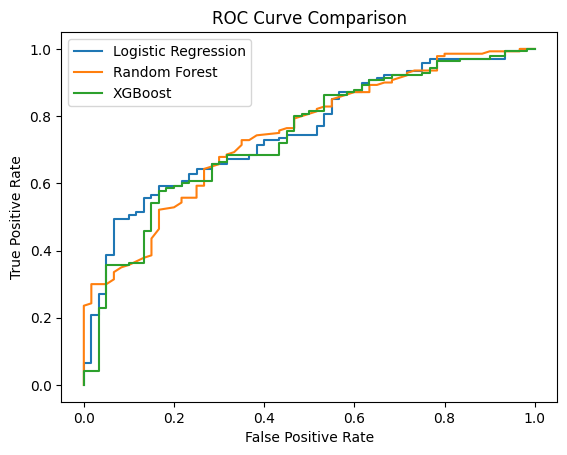

In [22]:
from sklearn.metrics import roc_curve

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)

plt.plot(fpr_lr, tpr_lr, label="Logistic Regression")

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
plt.plot(fpr_rf, tpr_rf, label="Random Forest")

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
plt.plot(fpr_xgb, tpr_xgb, label="XGBoost")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

Overfitting Analysis


In [23]:
from sklearn.metrics import roc_auc_score

# Logistic Regression
lr_train_auc = roc_auc_score(y_train, lr_model.predict_proba(X_train_scaled)[:, 1])
lr_test_auc  = roc_auc_score(y_test,  lr_model.predict_proba(X_test_scaled)[:, 1])

# Random Forest
rf_train_auc = roc_auc_score(y_train, rf_model.predict_proba(X_train)[:, 1])
rf_test_auc  = roc_auc_score(y_test,  rf_model.predict_proba(X_test)[:, 1])

# XGBoost
xgb_train_auc = roc_auc_score(y_train, xgb_model.predict_proba(X_train)[:, 1])
xgb_test_auc  = roc_auc_score(y_test,  xgb_model.predict_proba(X_test)[:, 1])

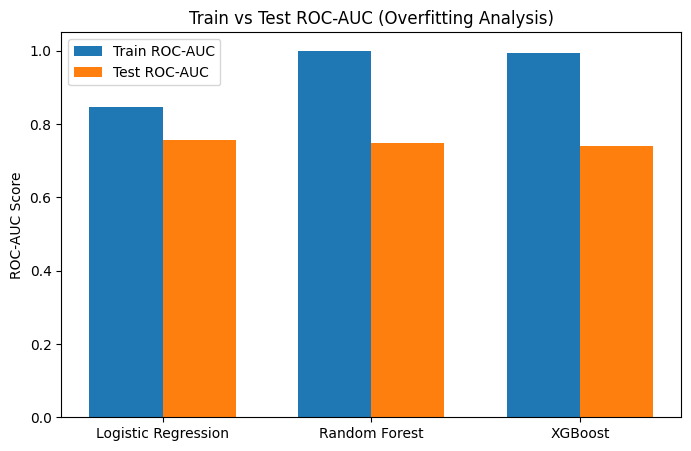

In [24]:
models = ['Logistic Regression', 'Random Forest', 'XGBoost']

train_scores = [lr_train_auc, rf_train_auc, xgb_train_auc]
test_scores  = [lr_test_auc,  rf_test_auc,  xgb_test_auc]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(x - width/2, train_scores, width, label='Train ROC-AUC')
plt.bar(x + width/2, test_scores,  width, label='Test ROC-AUC')

plt.xticks(x, models)
plt.ylabel("ROC-AUC Score")
plt.title("Train vs Test ROC-AUC (Overfitting Analysis)")
plt.legend()

plt.show()

### Feature Importance Analysis

Feature importance from the Random Forest model is inspected to gain insight into
which attributes most strongly influence predictions. This step was included to
improve transparency and better understand model behaviour.


In [27]:
xgb_feature_importance = pd.Series(
    xgb_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

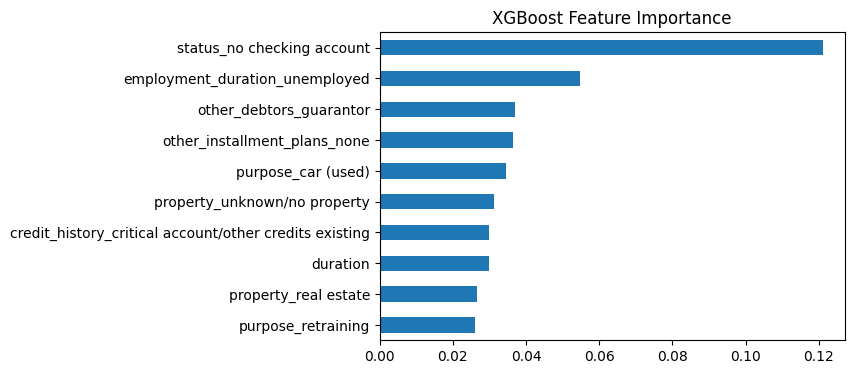

In [28]:
xgb_feature_importance.head(10).plot(kind="barh", figsize=(6,4))
plt.title("XGBoost Feature Importance")
plt.gca().invert_yaxis()
plt.show()

Model Comparison

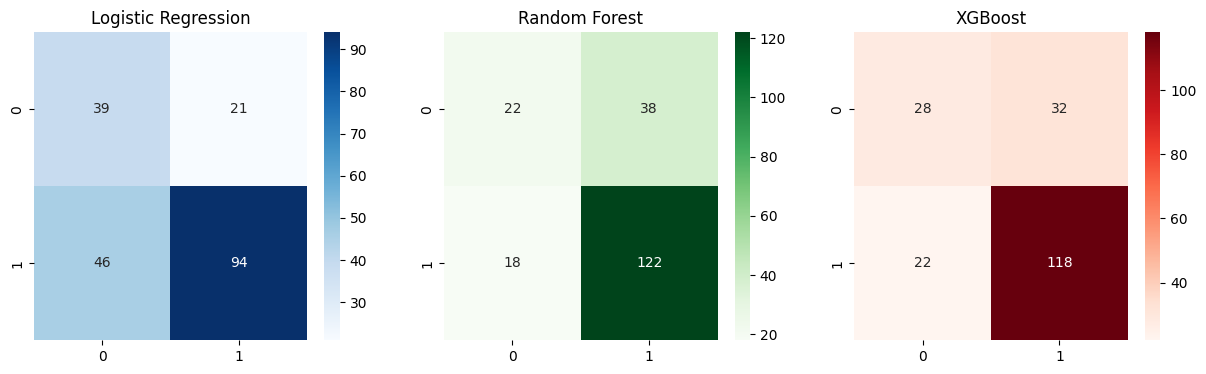

In [29]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues")
plt.title("Logistic Regression")

plt.subplot(1,3,2)
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens")
plt.title("Random Forest")

plt.subplot(1,3,3)
sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Reds")
plt.title("XGBoost")

plt.show()

In [30]:
# Logistic Regression
lr_recall = recall_score(y_test, lr_model.predict(X_test_scaled))

# Random Forest
rf_recall = recall_score(y_test, rf_model.predict(X_test))

# XGBoost
xgb_recall = recall_score(y_test, xgb_model.predict(X_test))

In [31]:
comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [lr_accuracy, rf_accuracy, xgb_accuracy],
    "ROC-AUC": [lr_roc_auc, rf_roc_auc, xgb_roc_auc],
    "Recall": [lr_recall, rf_recall, xgb_recall]
})

comparison_df


,Model,Accuracy,ROC-AUC,Recall
0,Logistic Regression,0.665,0.755119,0.671429
1,Random Forest,0.720,0.746964,0.871429
2,XGBoost,0.730,0.739405,0.842857


Explainable AI using SHAP

In [32]:
!pip install shap

In [33]:
import shap


In [34]:
explainer_xgb = shap.TreeExplainer(xgb_model)

In [35]:
shap_values_xgb = explainer_xgb.shap_values(X_test.values)

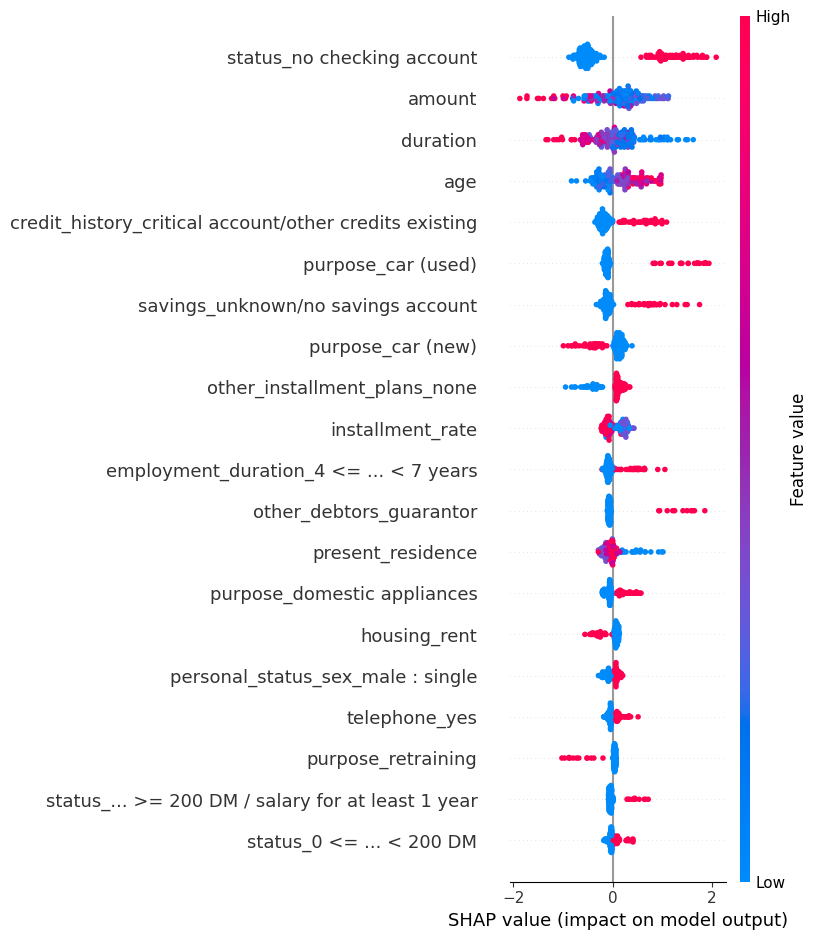

In [36]:
shap.summary_plot(shap_values_xgb, X_test)

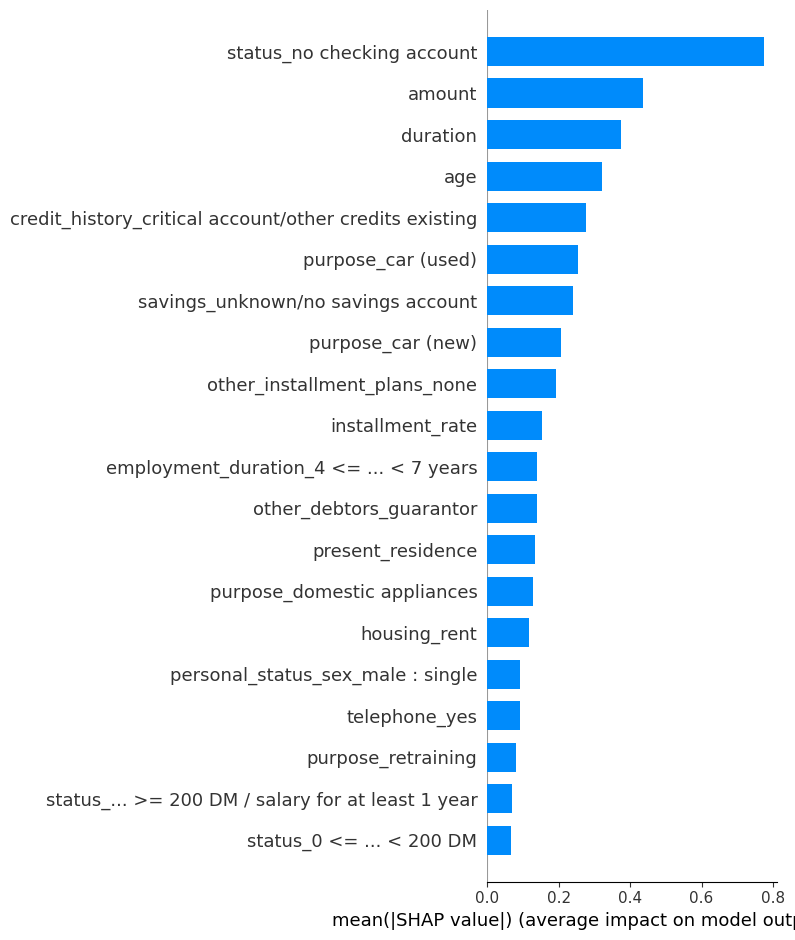

In [37]:
shap.summary_plot(shap_values_xgb, X_test, plot_type="bar")

SHAP analysis reveals that loan amount, credit history, and checking account status strongly influence credit risk predictions. Features such as higher loan amounts and unstable financial indicators increase predicted default risk, while stable employment and lower loan duration reduce the predicted risk.

### Limitations

This implementation assumes static borrower behaviour and does not capture
temporal changes in credit patterns. Additionally, no extensive hyperparameter
tuning was performed, as the primary goal was to understand baseline model
behaviour.
